## Lab 3: Kaj and Drew

We are going to start by taking all of the files of faces and flatten all 2D images to a 1D array.

This gives use 3279 rows which is the number of pictures as well as 16129 (127^2)

In [21]:
import os
import numpy as np
from PIL import Image

# Directory where your images are stored
image_dir = './cropped_faces'

# Function to load and flatten the images
def load_and_flatten_images(image_dir):
    image_list = []
    
    # Loop through all files in the directory
    for filename in sorted(os.listdir(image_dir)):
        if filename.endswith('.jpg') or filename.endswith('.png'):  # Adjust file types as needed
            # Open the image using PIL (Pillow)
            img = Image.open(os.path.join(image_dir, filename))
           
            # Ensure the image is in grayscale (mode 'L' for grayscale)
            img = img.convert('L')
           
            # Resize image to (128, 128) if it's not already
            img = img.resize((127, 127))
           
            # Convert image to numpy array and flatten it to 1D
            img_array = np.array(img).flatten()
           
            # Append the flattened image to the list
            image_list.append(img_array)
   
    # Convert the list of flattened images to a numpy array
    image_matrix = np.array(image_list)
   
    return image_matrix

# Load and flatten all images
image_matrix = load_and_flatten_images(image_dir)

# Print the shape of the resulting matrix (should be (num_images, 16129))
print(f"Shape of the image matrix: {image_matrix.shape}")

Shape of the image matrix: (3279, 16129)


### 1D to Image
This code takes the 1D array of the flattened images and turns them back into an image. We printed the first 5 MIDN

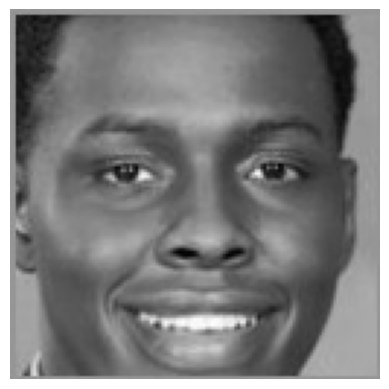

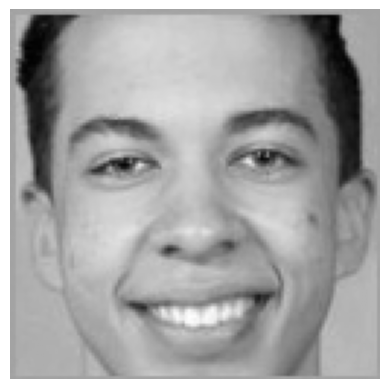

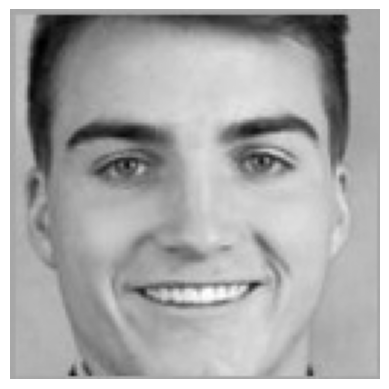

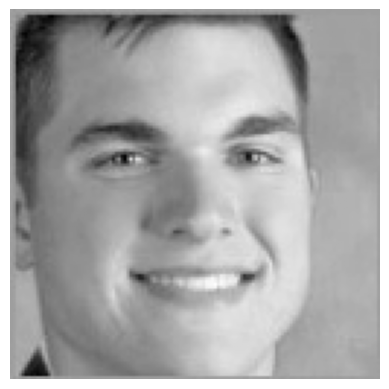

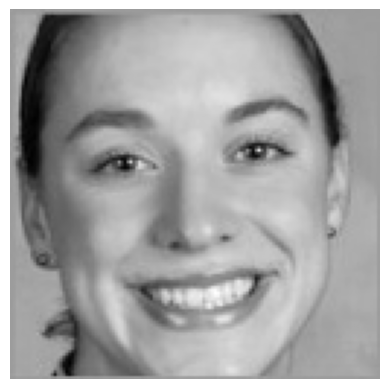

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def display_image_from_row(flat_row, image_size=(127, 127)):
    """
    Given a flattened row (1D array), reshape it to the image size and display the image.
    
    :param flat_row: The flattened image (1D array).
    :param image_size: Tuple specifying the original image size, default is (128, 128).
    """
    # Reshape the flat row back into the original 2D image shape
    image = flat_row.reshape(image_size)
    
    # Display the image using matplotlib
    plt.imshow(image, cmap='gray')  # 'gray' colormap for grayscale images
    plt.axis('off')  # Turn off axis labels
    plt.show()

# Example usage:
# Assuming image_matrix is the matrix you generated earlier and you want to display the first image row
for i in range(0,5):
    display_image_from_row(image_matrix[i])

### Singular Values
As seen below, the singular values quickly become small. This indicates that after a certain point, the singular values are not very defining for the matrix. However, more testing with outputting images is needed to know at what point do these values become vital. It is hard to apply a numerical value to this "drop off"

test
Singular values: [1.06166378e+06 1.10442669e+05 7.81789201e+04 ... 2.84548495e+02
 2.79524702e+02 2.76133249e+02]


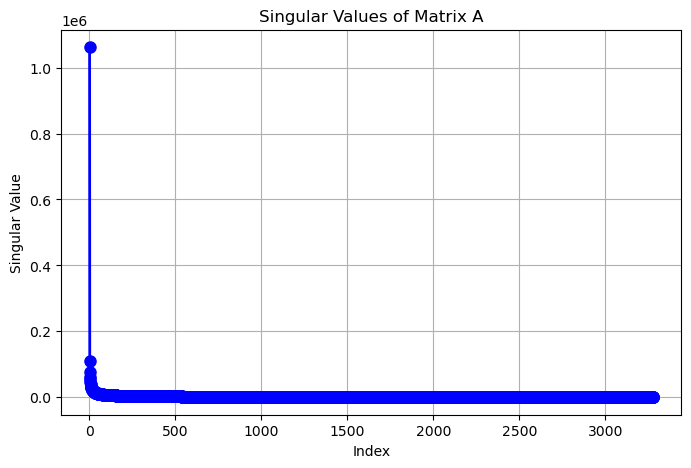

Rank of the matrix: 3279


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Example matrix A (you can replace this with your matrix)
A = image_matrix

# Compute singular values using SVD
U, sigma, Vt = np.linalg.svd(A)
print("test")

# Print singular values
print("Singular values:", sigma)

#
# Plot singular values
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(sigma)+1), sigma, 'bo-', linewidth=2, markersize=8)
plt.title("Singular Values of Matrix A")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()

# Calculate the numerical rank of the matrix
# Using a tolerance to account for floating point precision
tol = 1e-10
rank = np.sum(sigma > tol)
print(f"Rank of the matrix: {rank}")

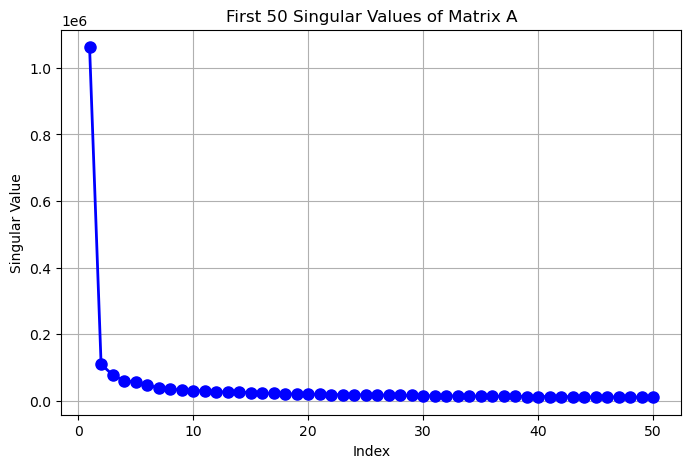

In [32]:
# Number of singular values to plot
num_values_to_plot = 50

# Slice the singular values array to get first 10 (or less if not enough)
singular_values_to_plot = sigma[:num_values_to_plot]

# Plot the first 10 singular values
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(singular_values_to_plot) + 1), singular_values_to_plot, 'bo-', linewidth=2, markersize=8)
plt.title("First " + str(num_values_to_plot) + " Singular Values of Matrix A")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()

### Low-rank Approx Start
This code crops the matrices based off a decided k value. Our estimated value of 30 was off as many features are missing. More testing in the next code block.

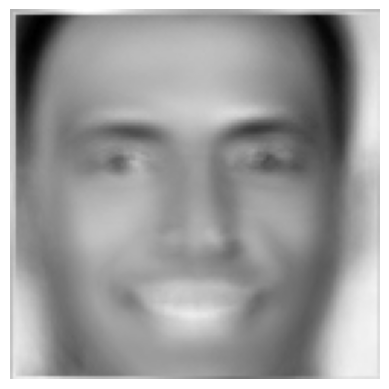

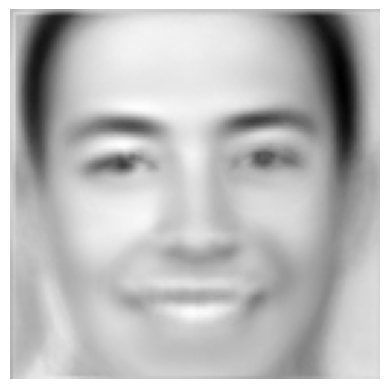

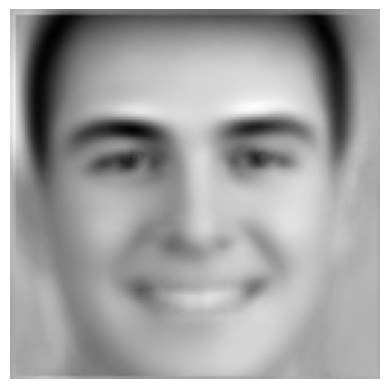

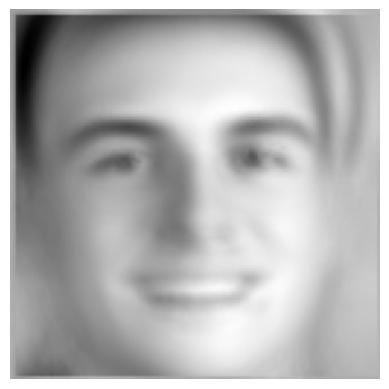

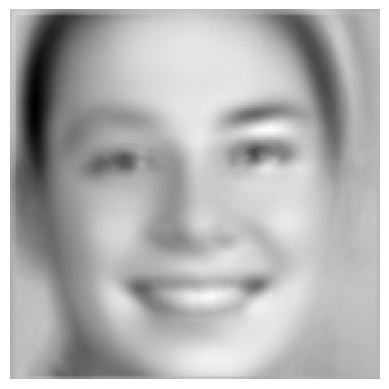

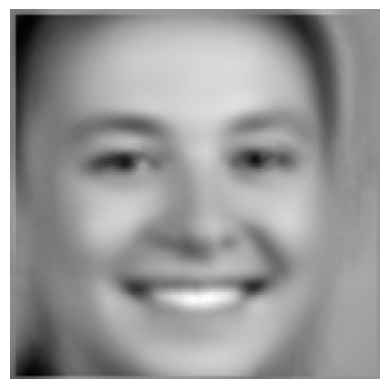

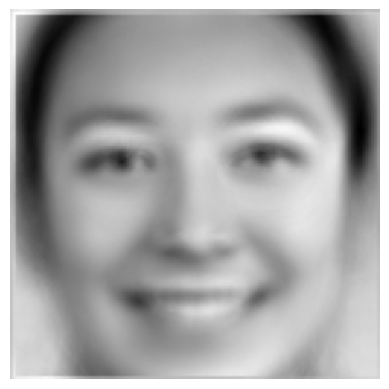

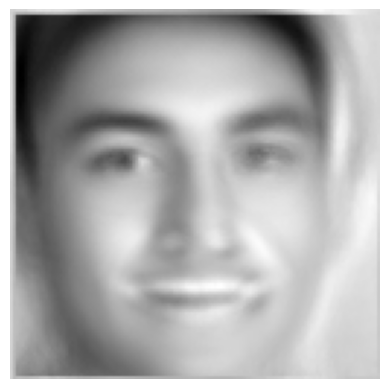

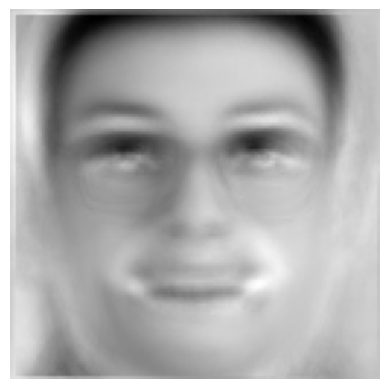

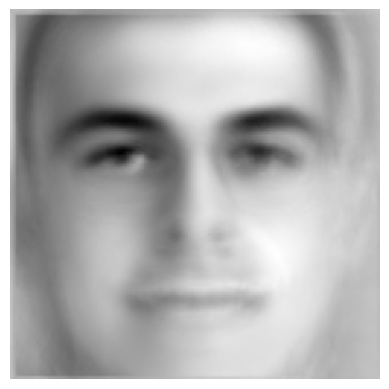

In [55]:
# Suppose you already have U, s, Vt from SVD:
# U: shape (m, m)
# s: shape (min(m, n),)  # singular values vector
# Vt: shape (n, n)

# Example k (number of components to keep)
k = 30 # set this to your desired number of components

# Crop U to first k columns
Ucropped = U[:, :k]

# Crop singular values vector s to first k values
Scropped = sigma[:k]

# Crop Vt to first k rows
Vcropped = Vt[:k, :]

# Convert Scropped (vector) into a diagonal matrix
Scropped_matrix = np.diag(Scropped)

# Multiply to get the reconstructed matrix
ANew = np.dot(Ucropped, np.dot(Scropped_matrix, Vcropped))

for i in range(0,10):
    display_image_from_row(ANew[i])

### Unique Faces to Find Ideal K
Here we chose a list of MIDN with very different faces. We looked to see at what k values did certain features expose themselves.

In [ ]:
unqiue_list = ["face_260300.jpg", "face_274146.jpg", "face_274218.jpg", "face_274266.jpg", "face_274008.jpg", "face_2777050.jpg", "face_280012.jpg", "face_286966.jpg", "face_271050.jpg"]
                #dark, F, smile    F, glasses, smile   black, M, smile   white,M,smi,glass   white, M, no-smi  F,smile,white         dark,M, no-smi   glass, M, no-smi     F, smile, tilt